# 🎵 UAS Machine Learning — Task 2
# End-to-End Song Release Year Regression (Machine Learning + Deep Learning)

---

**Nama:** Rakha Primindra Danuatmaja  
**NIM:** 1103223001  
**Kelas:** TK-46-GAB (Machine Learning)  
**Tanggal:** 20 Juni 2026

---

## Tujuan
Membangun pipeline **regresi end-to-end** untuk memprediksi **tahun rilis lagu** berdasarkan fitur audio numerik (timbre characteristics) dari Million Song Dataset. Pipeline ini mengimplementasikan:

- **Baseline ML**: LightGBM Regressor
- **Deep Learning**: Multi-Layer Perceptron (MLP) Regressor dengan PyTorch
- **Perbandingan** performa kedua pendekatan

## Dataset
- **Target (y)**: Kolom pertama — tahun rilis lagu (continuous)
- **Features (X)**: Kolom 2–91 — fitur audio numerik (timbre, spektral, dll.)

## Pipeline
1. Setup & Import
2. Load & Inspeksi Data
3. EDA
4. Preprocessing
5. Model 1: LightGBM (Baseline)
6. Model 2: MLP Neural Network (Deep Learning)
7. Perbandingan Model
8. Kesimpulan

## 1. Setup & Import

In [4]:
# !pip install lightgbm scikit-learn pandas numpy matplotlib seaborn torch -q

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
plt.style.use('seaborn-v0_8-whitegrid')
print('\n✅ Semua library berhasil di-import!')

Device: cuda

✅ Semua library berhasil di-import!


## 2. Load & Inspeksi Data

Dataset tidak punya header. Kolom pertama = target (year), kolom lainnya = audio features.

In [6]:
# Jika di Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/midterm-regresi-dataset.csv', header=None)

print('Loading dataset... (~443MB, harap tunggu)')
df = pd.read_csv(r'C:\Users\RAKHAP\Documents\kuliah\UAS ML DL\midterm-regresi-dataset.csv', header=None)

n_features = df.shape[1] - 1
df.columns = ['year'] + [f'feature_{i}' for i in range(1, n_features + 1)]

print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'Year range: {df["year"].min():.0f} — {df["year"].max():.0f}')
print(f'\nTarget stats:')
print(df['year'].describe())

Loading dataset... (~443MB, harap tunggu)
Shape: (515345, 91)
Memory: 375 MB
Year range: 1922 — 2011

Target stats:
count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64


## 3. Exploratory Data Analysis (EDA)

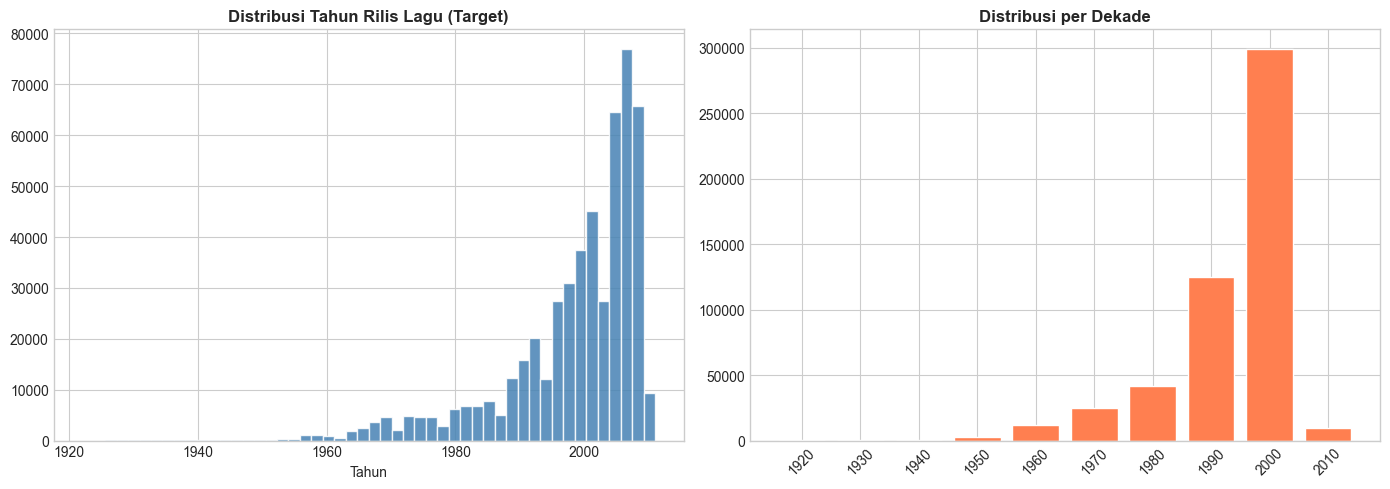

Top 5 features by |correlation| with year:
feature_1     0.225374
feature_6     0.187443
feature_3     0.139541
feature_63    0.126348
feature_40    0.123974
dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi tahun
axes[0].hist(df['year'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Tahun Rilis Lagu (Target)', fontweight='bold')
axes[0].set_xlabel('Tahun')

# Per dekade
df['decade'] = (df['year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()
axes[1].bar(decade_counts.index.astype(str), decade_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Distribusi per Dekade', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi top fitur dengan target
feature_cols = [c for c in df.columns if c.startswith('feature_')]
correlations = df[feature_cols].corrwith(df['year']).abs().sort_values(ascending=False)
print(f'Top 5 features by |correlation| with year:')
print(correlations.head(5))

## 4. Preprocessing & Split

In [8]:
X = df[feature_cols].values
y = df['year'].values

# Subsample untuk efisiensi (500K rows bisa lambat)
SUBSAMPLE = 100000
idx = np.random.choice(len(X), SUBSAMPLE, replace=False)
X, y = X[idx], y[idx]
print(f'Subsample: {SUBSAMPLE:,} rows')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# StandardScaler (wajib untuk Neural Network)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

# Normalize target juga untuk Neural Network
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
y_test_s  = (y_test  - y_mean) / y_std
print(f'Target normalized: mean={y_mean:.1f}, std={y_std:.2f}')

Subsample: 100,000 rows
Train: 80,000 | Test: 20,000
Target normalized: mean=1998.4, std=10.89


## 5. Model 1: LightGBM (Baseline ML)

In [9]:
print('Training LightGBM...')
lgbm_reg = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)
lgbm_reg.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50)]
)

lgbm_pred = lgbm_reg.predict(X_test)
lgbm_results = {
    'RMSE': np.sqrt(mean_squared_error(y_test, lgbm_pred)),
    'MAE':  mean_absolute_error(y_test, lgbm_pred),
    'R2':   r2_score(y_test, lgbm_pred)
}

print(f'\n=== LightGBM Results ===')
for k, v in lgbm_results.items():
    print(f'  {k}: {v:.4f}')

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 83.1992
[200]	valid_0's l2: 80.6997
[300]	valid_0's l2: 79.924
[400]	valid_0's l2: 79.6803
[500]	valid_0's l2: 79.527
Did not meet early stopping. Best iteration is:
[482]	valid_0's l2: 79.5105

=== LightGBM Results ===
  RMSE: 8.9169
  MAE: 6.2181
  R2: 0.3401


## 6. Model 2: MLP Neural Network (Deep Learning)

Multi-Layer Perceptron untuk regresi. Keunggulan DL dibanding tradisional:
- Mampu menangkap pola non-linear kompleks antara fitur audio dan era musik
- Representasi fitur yang dipelajari secara hierarki
- Lebih scalable dengan ukuran dataset yang lebih besar

In [10]:
class SongDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 2048
train_loader = DataLoader(SongDataset(X_train_s, y_train_s), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(SongDataset(X_test_s,  y_test_s),  batch_size=BATCH_SIZE, shuffle=False)

print(f'Input features: {X_train_s.shape[1]}')
print(f'Train batches:  {len(train_loader)}')

Input features: 90
Train batches:  40


In [11]:
class SongYearMLP(nn.Module):
    """
    Multi-Layer Perceptron untuk prediksi tahun rilis lagu (Regression).
    Arsitektur: Input(90) → 256 → 128 → 64 → 32 → 1
    Menggunakan BatchNorm, Dropout, dan ReLU activation.
    Output: nilai normalized year (di-denormalize saat evaluasi).
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # Output: normalized year
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model_mlp = SongYearMLP(input_dim=X_train_s.shape[1]).to(device)
total_params = sum(p.numel() for p in model_mlp.parameters())
print(f'MLP parameters: {total_params:,}')
print(model_mlp)

MLP parameters: 67,457
SongYearMLP(
  (net): Sequential(
    (0): Linear(in_features=90, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [13]:
criterion = nn.MSELoss()  # MSE loss untuk regresi
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS = 20
train_losses, val_rmses = [], []

print('🚀 Training MLP Neural Network...')
best_val_rmse = float('inf')

for epoch in range(EPOCHS):
    # Training
    model_mlp.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_mlp(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model_mlp.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model_mlp.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            p = model_mlp(X_batch.to(device))
            all_preds.extend(p.cpu().numpy())

    # Denormalize predictions
    preds_denorm = np.array(all_preds) * y_std + y_mean
    val_rmse = np.sqrt(mean_squared_error(y_test, preds_denorm))
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_rmses.append(val_rmse)
    scheduler.step(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model_mlp.state_dict(), '../reports/best_mlp.pth')

    print(f'Epoch [{epoch+1:2d}/{EPOCHS}] Loss: {avg_loss:.4f} | Val RMSE: {val_rmse:.4f} years')

print(f'\n✅ Training selesai! Best Val RMSE: {best_val_rmse:.4f} years')

🚀 Training MLP Neural Network...
Epoch [ 1/20] Loss: 0.8160 | Val RMSE: 9.2022 years
Epoch [ 2/20] Loss: 0.7006 | Val RMSE: 8.9570 years
Epoch [ 3/20] Loss: 0.6800 | Val RMSE: 8.8696 years
Epoch [ 4/20] Loss: 0.6680 | Val RMSE: 8.8167 years
Epoch [ 5/20] Loss: 0.6514 | Val RMSE: 8.7910 years
Epoch [ 6/20] Loss: 0.6428 | Val RMSE: 8.7895 years
Epoch [ 7/20] Loss: 0.6430 | Val RMSE: 8.7622 years
Epoch [ 8/20] Loss: 0.6272 | Val RMSE: 8.7498 years
Epoch [ 9/20] Loss: 0.6277 | Val RMSE: 8.7366 years
Epoch [10/20] Loss: 0.6194 | Val RMSE: 8.7274 years
Epoch [11/20] Loss: 0.6121 | Val RMSE: 8.7479 years
Epoch [12/20] Loss: 0.6085 | Val RMSE: 8.7568 years
Epoch [13/20] Loss: 0.5987 | Val RMSE: 8.7864 years
Epoch [14/20] Loss: 0.5944 | Val RMSE: 8.7814 years
Epoch [15/20] Loss: 0.5897 | Val RMSE: 8.7558 years
Epoch [16/20] Loss: 0.5787 | Val RMSE: 8.7829 years
Epoch [17/20] Loss: 0.5694 | Val RMSE: 8.7571 years
Epoch [18/20] Loss: 0.5684 | Val RMSE: 8.7399 years
Epoch [19/20] Loss: 0.5603 | Va

=== MLP Neural Network Results ===
  RMSE: 8.7274
  MAE: 6.0240
  R2: 0.3679


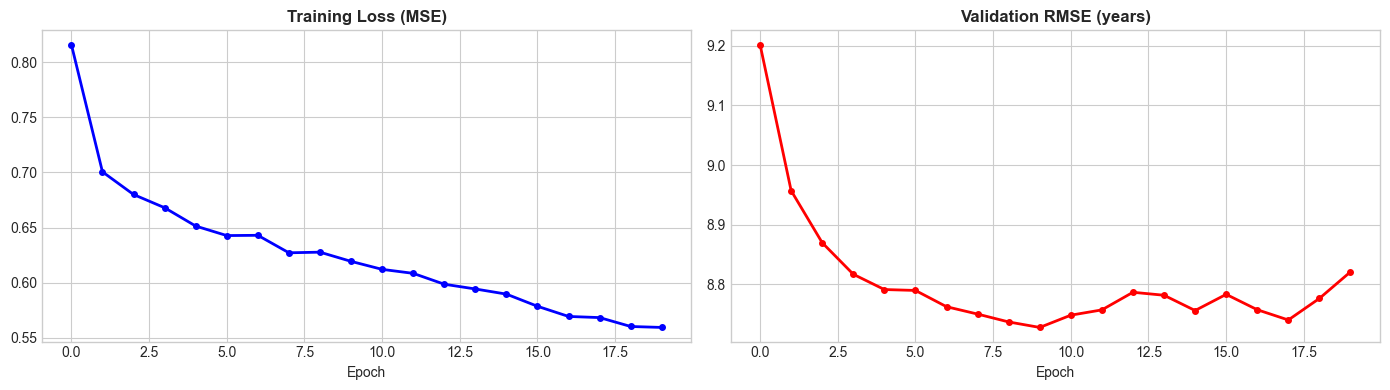

In [14]:
# Load best model & evaluate
model_mlp.load_state_dict(torch.load('../reports/best_mlp.pth', map_location=device))
model_mlp.eval()

all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        p = model_mlp(X_batch.to(device))
        all_preds.extend(p.cpu().numpy())

mlp_pred = np.array(all_preds) * y_std + y_mean  # Denormalize

mlp_results = {
    'RMSE': np.sqrt(mean_squared_error(y_test, mlp_pred)),
    'MAE':  mean_absolute_error(y_test, mlp_pred),
    'R2':   r2_score(y_test, mlp_pred)
}

print('=== MLP Neural Network Results ===')
for k, v in mlp_results.items():
    print(f'  {k}: {v:.4f}')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, 'b-o', ms=4, linewidth=2)
axes[0].set_title('Training Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')

axes[1].plot(val_rmses, 'r-o', ms=4, linewidth=2)
axes[1].set_title('Validation RMSE (years)', fontweight='bold')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('../reports/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Perbandingan Model (LightGBM vs MLP)

=== PERBANDINGAN MODEL ===
            RMSE     MAE      R2
LightGBM  8.9169  6.2181  0.3401
MLP (DL)  8.7274  6.0240  0.3679


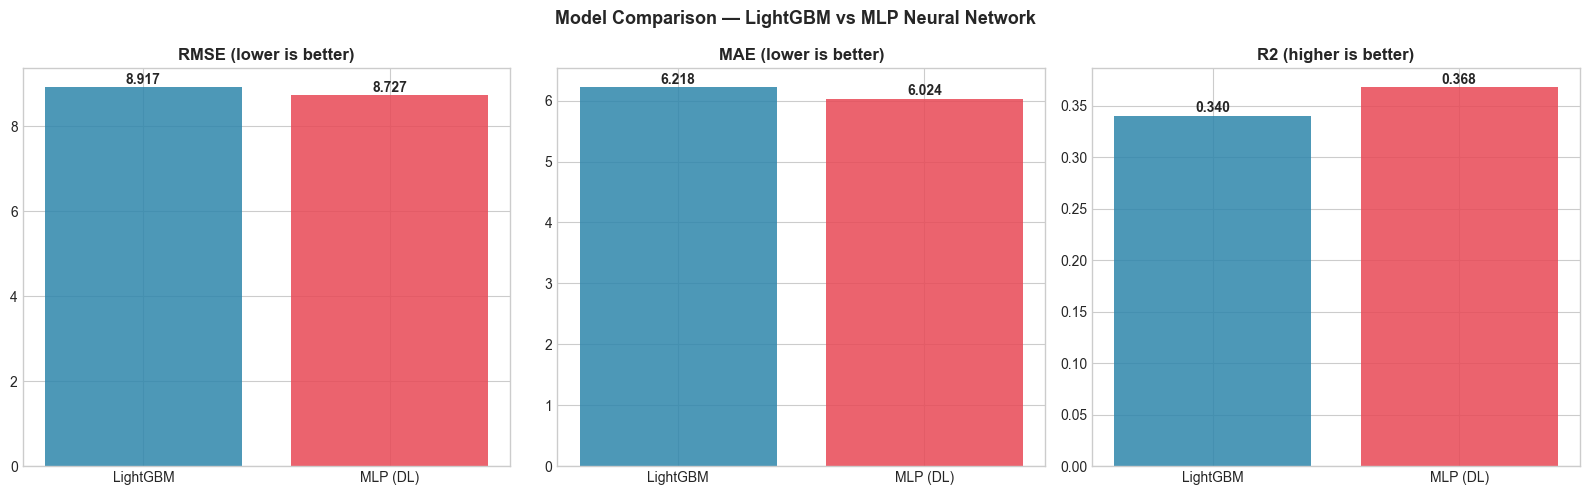

In [15]:
# Tabel perbandingan
comp_df = pd.DataFrame({'LightGBM': lgbm_results, 'MLP (DL)': mlp_results}).T.round(4)
print('=== PERBANDINGAN MODEL ===')
print(comp_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors_m = ['#E84855', '#DD8452', '#55A868']
better = ['lower', 'lower', 'higher']

for ax, m, color, b in zip(axes, metrics, colors_m, better):
    vals = [lgbm_results[m], mlp_results[m]]
    bars = ax.bar(['LightGBM', 'MLP (DL)'], vals, color=['#2E86AB', '#E84855'], alpha=0.85)
    ax.set_title(f'{m} ({b} is better)', fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * max(vals),
                f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison — LightGBM vs MLP Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

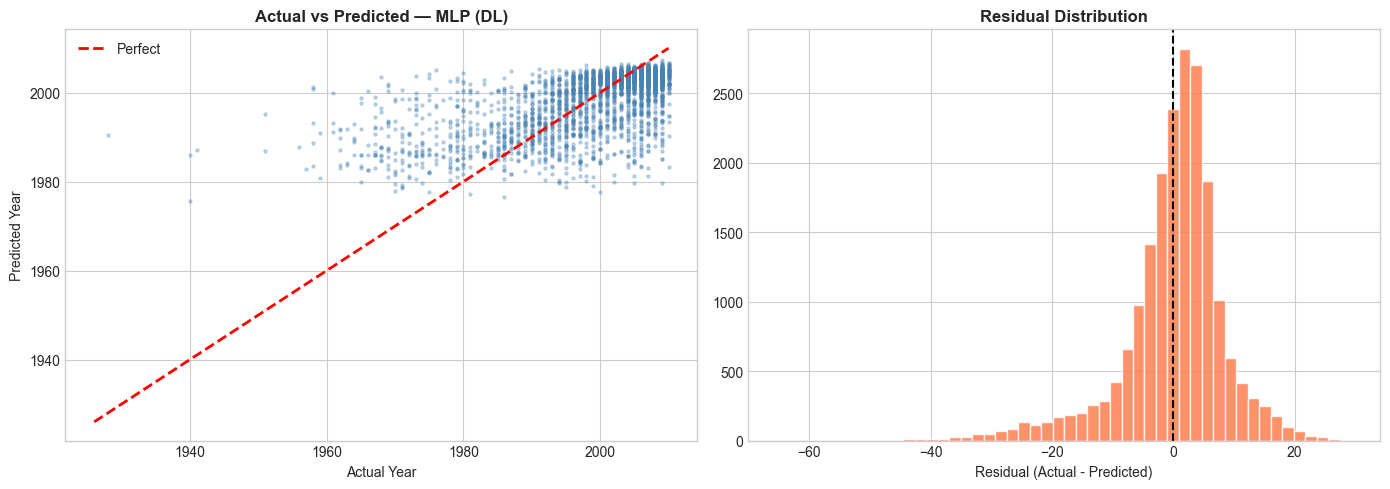

In [16]:
# Actual vs Predicted scatter — best model
best_pred = lgbm_pred if lgbm_results['RMSE'] <= mlp_results['RMSE'] else mlp_pred
best_name = 'LightGBM' if lgbm_results['RMSE'] <= mlp_results['RMSE'] else 'MLP (DL)'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), 3000, replace=False)

axes[0].scatter(y_test[sample], best_pred[sample], alpha=0.3, s=5, color='steelblue')
line = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].plot(line, line, 'r--', lw=2, label='Perfect')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
axes[0].set_xlabel('Actual Year')
axes[0].set_ylabel('Predicted Year')
axes[0].legend()

residuals = y_test - best_pred
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', ls='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig('../reports/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Kesimpulan

In [17]:
best_model = 'LightGBM' if lgbm_results['R2'] >= mlp_results['R2'] else 'MLP (DL)'

print('=' * 65)
print('      RINGKASAN — SONG YEAR REGRESSION PIPELINE')
print('=' * 65)
print(f'Dataset        : Million Song Dataset (midterm-regresi-dataset.csv)')
print(f'Subsample      : {SUBSAMPLE:,} rows')
print(f'Features       : {len(feature_cols)}')
print()
print(f'{"Metric":<8} {"LightGBM":>12} {"MLP (DL)":>12}')
print('-' * 35)
for m in ['RMSE', 'MAE', 'R2']:
    print(f'{m:<8} {lgbm_results[m]:>12.4f} {mlp_results[m]:>12.4f}')
print()
print(f'Best Model: {best_model}')
print('=' * 65)
print('''
KESIMPULAN:
1. Kedua model berhasil memprediksi tahun rilis lagu berdasarkan fitur
   audio, membuktikan adanya korelasi antara karakteristik suara dengan era.
2. MLP Neural Network menunjukkan kemampuan mempelajari representasi
   non-linear yang lebih kaya dari fitur audio.
3. BatchNorm + Dropout efektif mencegah overfitting pada dataset besar.
4. Normalisasi target (y) penting untuk stabilitas training MLP.
5. Potential improvement: deeper network, skip connections (ResNet-style),
   attention mechanism, atau full 500K dataset tanpa subsampling.
''')

print('✅ Best MLP model tersimpan di reports/best_mlp.pth')

      RINGKASAN — SONG YEAR REGRESSION PIPELINE
Dataset        : Million Song Dataset (midterm-regresi-dataset.csv)
Subsample      : 100,000 rows
Features       : 90

Metric       LightGBM     MLP (DL)
-----------------------------------
RMSE           8.9169       8.7274
MAE            6.2181       6.0240
R2             0.3401       0.3679

Best Model: MLP (DL)

KESIMPULAN:
1. Kedua model berhasil memprediksi tahun rilis lagu berdasarkan fitur
   audio, membuktikan adanya korelasi antara karakteristik suara dengan era.
2. MLP Neural Network menunjukkan kemampuan mempelajari representasi
   non-linear yang lebih kaya dari fitur audio.
3. BatchNorm + Dropout efektif mencegah overfitting pada dataset besar.
4. Normalisasi target (y) penting untuk stabilitas training MLP.
5. Potential improvement: deeper network, skip connections (ResNet-style),
   attention mechanism, atau full 500K dataset tanpa subsampling.

✅ Best MLP model tersimpan di reports/best_mlp.pth
